# Step 1 : Text Preprocessing

In [3]:
import pandas as pd
import numpy as np

In [2]:
# Choosing a IMDB Dataset from kaggle for performing Text Preprocessing steps for our understanding

In [3]:
df=pd.read_csv('IMDB Dataset.csv')

In [4]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


# 1. Lowering

In [5]:
df['review'][3]

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

In [6]:
df['review'][3].lower()

"basically there's a family where a little boy (jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />this movie is slower than a soap opera... and suddenly, jake decides to become rambo and kill the zombie.<br /><br />ok, first of all when you're going to make a film you must decide if its a thriller or a drama! as a drama the movie is watchable. parents are divorcing & arguing like in real life. and then we have jake with his closet which totally ruins all the film! i expected to see a boogeyman similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. as for the shots with jake: just ignore them."

In [7]:
# Now performing the lowering steps to complete feature
df['review']=df['review'].str.lower()

In [8]:
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,i am a catholic taught in parochial elementary...,negative
49998,i'm going to have to disagree with the previou...,negative


# 2. Removing HTML Tags

In [12]:
import re
def remove_html_tags(text):
    pattern=re.compile('<.*?>')
    return pattern.sub(r'',text)

In [13]:
# For Example 
text = "<p>I am learning <b>Natural Language Processing</b> from CampusX.</p>"
remove_html_tags(text)


'I am learning Natural Language Processing from CampusX.'

In [14]:
df['review']=df['review'].apply(remove_html_tags)

In [15]:
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,i am a catholic taught in parochial elementary...,negative
49998,i'm going to have to disagree with the previou...,negative


# 3. Remove URL

In [16]:
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

In [17]:
# For example
text = "Learn NLP from https://campusx.in and visit www.google.com"
remove_url(text)

'Learn NLP from  and visit '

# 4. Remove Punctutation

In [18]:
import string 

In [19]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [20]:
exclude=string.punctuation

In [23]:
def remove_punc(text):
    for char in exclude:
        text=text.replace(char,'')
    return text

In [26]:
text='string! rahul:: glass@ '
remove_punc(text)

'string rahul glass '

In [29]:
# Above method is bit slower in case of large dataset so alternate method is:
def remove_punc_1(text):
    return text.translate(str.maketrans('','',exclude))

In [30]:
text2='string! rahul:: glass@ '
remove_punc_1(text2)

'string rahul glass '

# 5. Chat Word Treatment

In [31]:
chat_words = {
    "ASAP": "As Soon As Possible",
    "AFK": "Away From Keyboard",
    "AKA": "Also Known As",
    "ATM": "At The Moment",
    "AFAIK": "As Far As I Know",
    "B4": "Before",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BC": "Because",
    "BF": "Boyfriend",
    "BFF": "Best Friends Forever",
    "BRB": "Be Right Back",
    "BRO": "Brother/Friend",
    "BTW": "By The Way",
    "CU": "See You",
    "CUL8R": "See You Later",
    "DIY": "Do It Yourself",
    "DM": "Direct Message",
    "FAQ": "Frequently Asked Questions",
    "FB": "Facebook",
    "FYI": "For Your Information",
    "GF": "Girlfriend",
    "GG": "Good Game",
    "GM": "Good Morning",
    "GN": "Good Night",
    "GR8": "Great",
    "GTG": "Got To Go",
    "HAND": "Have A Nice Day",
    "HBD": "Happy Birthday",
    "HMU": "Hit Me Up",
    "IDC": "I Don't Care",
    "IDK": "I Don't Know",
    "IIRC": "If I Recall Correctly",
    "IKR": "I Know Right",
    "ILY": "I Love You",
    "IMO": "In My Opinion",
    "IMHO": "In My Humble Opinion",
    "IRL": "In Real Life",
    "JK": "Just Kidding",
    "K": "Okay",
    "L8R": "Later",
    "LMK": "Let Me Know",
    "LOL": "Laughing Out Loud",
    "NBD": "No Big Deal",
    "NGL": "Not Gonna Lie",
    "NP": "No Problem",
    "NVM": "Never Mind",
    "OMG": "Oh My God",
    "OMW": "On My Way",
    "OOTD": "Outfit Of The Day",
    "OP": "Original Poster",
    "PFA": "Please Find Attached",
    "PLS": "Please",
    "PPL": "People",
    "ROFL": "Rolling On Floor Laughing",
    "SMH": "Shaking My Head",
    "SRY": "Sorry",
    "SUP": "What's Up",
    "TC": "Take Care",
    "TMI": "Too Much Information",
    "THX": "Thanks",
    "TIA": "Thanks In Advance",
    "TTYL": "Talk To You Later",
    "TY": "Thank You",
    "TYSM": "Thank You So Much",
    "U": "You",
    "UR": "Your/You're",
    "WBU": "What About You",
    "WFH": "Work From Home",
    "WTH": "What The Heck",
    "YOLO": "You Only Live Once",
    "YW": "You're Welcome",
    "XOXO": "Hugs And Kisses",
    "MSG": "Message",
    "BRB": "Be Right Back"
}

In [38]:
def chat_conversion(text):
    new_text=[]
    for w in text.split():
        if w.upper() in chat_words:
            new_text.append(chat_words[w.upper()])
        else:
            new_text.append(w)
    return " ".join(new_text)
            

In [40]:
chat_conversion('IMHO gudu is the best ')

'In My Humble Opinion gudu is the best'

# 6. Spelling Correction

In [42]:
from textblob import TextBlob

In [52]:
incorrect_string='condiantions of Poweer and Stratiegy is uselless'

In [53]:
textblb=TextBlob(incorrect_string)

In [54]:
textblb.correct().string

'conditions of Power and Strategy is useless'

# 7. Removing StopWords

In [56]:
from nltk.corpus import stopwords

In [58]:
exclude=stopwords.words('english')

In [67]:
def remove_stopwords(text):
    new_text=[]
    for w in text.split():
        if w in stopwords.words('english'):
            new_text.append('')
        else:
            new_text.append(w)
    return " ".join(new_text)

In [68]:
# For example
text = "This is a very good movie and I like it"
remove_stopwords(text)

'This    good movie  I like '

# 8. Handeling Emoji

In [ ]:
# We have two method 1. Remove Emoji and second one is to replace with text by showing actual meaning of that emoji

In [69]:
def remove_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)

    return emoji_pattern.sub(r'', text)

In [70]:
remove_emoji("Hey buddy 😊 How are you today?")

'Hey buddy  How are you today?'

In [71]:
# Replace Emoji with its text 
import emoji
print(emoji.demojize('Python is 🔥'))

Python is :fire:


In [73]:
print(emoji.demojize('I love Machine Learning ❤️'))

I love Machine Learning :red_heart:


# 9. Tokenization

In [74]:
# 1.Word Tokenize
# 2.Sentence Tokenize

### For Tokenization 1st method is Split function
# Word Tokenization


In [81]:
sent1='The Taj Mahal was made up for Mumtaj'
sent1.split()

['The', 'Taj', 'Mahal', 'was', 'made', 'up', 'for', 'Mumtaj']

In [78]:
# Sentence Tokenization
sent2='The Taj Mahal was made up for Mumtaj, My name is Rahul, My name is Riya'
sent2.split(',')

['The Taj Mahal was made up for Mumtaj',
 ' My name is Rahul',
 ' My name is Riya']

In [79]:
# Problem in split function
sent3='I went to Delhi! yesterday'
sent3.split()

['I', 'went', 'to', 'Delhi!', 'yesterday']

In [80]:
sent4='I went to Delhi! yesterday? What is your name?'
sent4.split('.')

['I went to Delhi! yesterday? What is your name?']

### For Tokenization 2nd Method is 
#  Regex Function

In [82]:
import re

sent3 = 'I am going to delhi!'
tokens = re.findall(r'[\w]+', sent3)
tokens

['I', 'am', 'going', 'to', 'delhi']

In [83]:
text = """Lorem Ipsum is simply dummy text of the printing and typesetting industry?
Lorem Ipsum has been the industry's standard dummy text ever since the 1500s,
when an unknown printer took a galley of type and scrambled it to make a type specimen book."""
    
sentences = re.compile('[.!?] ').split(text)
sentences

["Lorem Ipsum is simply dummy text of the printing and typesetting industry?\nLorem Ipsum has been the industry's standard dummy text ever since the 1500s,\nwhen an unknown printer took a galley of type and scrambled it to make a type specimen book."]

# Sent_Tokenize and Word_Tokenize

In [84]:
from nltk.tokenize import word_tokenize,sent_tokenize

In [85]:
sent1='My name is Gudu and i am 90 years old'
word_tokenize(sent1)

['My', 'name', 'is', 'Gudu', 'and', 'i', 'am', '90', 'years', 'old']

In [86]:
text = """Lorem Ipsum is simply dummy text of the printing and typesetting industry?
Lorem Ipsum has been the industry's standard dummy text ever since the 1500s,
when an unknown printer took a galley of type and scrambled it to make a type specimen book."""
sent_tokenize(text)

['Lorem Ipsum is simply dummy text of the printing and typesetting industry?',
 "Lorem Ipsum has been the industry's standard dummy text ever since the 1500s,\nwhen an unknown printer took a galley of type and scrambled it to make a type specimen book."]

In [87]:
sent5 = 'I have a Ph.D in A.I'

sent6 = "We're here to help! mail us at nks@gmail.com"

sent7 = 'A 5km ride cost $10.50'

In [88]:
word_tokenize(sent5)

['I', 'have', 'a', 'Ph.D', 'in', 'A.I']

In [89]:
word_tokenize(sent6)

['We',
 "'re",
 'here',
 'to',
 'help',
 '!',
 'mail',
 'us',
 'at',
 'nks',
 '@',
 'gmail.com']

In [90]:
word_tokenize(sent7)

['A', '5km', 'ride', 'cost', '$', '10.50']

# Spacy

In [91]:
import spacy

In [92]:
nlp=spacy.load('en_core_web_sm')

In [93]:
doc1=nlp(sent5)
doc2=nlp(sent6)
doc3=nlp(sent7)

In [94]:
for token in doc1:
    print(token)

I
have
a
Ph
.
D
in
A.I


In [95]:
for token in doc2:
    print(token)

We
're
here
to
help
!
mail
us
at
nks@gmail.com


In [96]:
for token in doc3:
    print(token)

A
5
km
ride
cost
$
10.50


# 10. Stemming

In [97]:
from nltk.stem.porter import PorterStemmer

In [98]:
ps=PorterStemmer()

In [99]:
def stem_words(text):
    return " ".join([ps.stem(word) for word in text.split()])

In [100]:
# For Example
sample='walks walked walking walk'
stem_words(sample)

'walk walk walk walk'

In [ ]:
# Important Note: "Stemming is the process of reducing inflection in words to their root forms such as mapping
# a group of words to the same stem even if the stem itself is not a valid word in the language."

In [ ]:
# So due to above reason Lemmatization is used

# Lemmitization

In [1]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

from nltk.stem import WordNetLemmatizer

wordnet_lemmatizer = WordNetLemmatizer()

sentence = "He was running and eating at same time. He has bad habit of swimming after playing long hours in the Sun."

punctuations = "?:!.,;"
sentence_words = nltk.word_tokenize(sentence)

for word in sentence_words[:]:
    if word in punctuations:
        sentence_words.remove(word)

print("{0:20}{1:20}".format("Word", "Lemma"))

for word in sentence_words:
    print("{0:20}{1:20}".format(word,
                                wordnet_lemmatizer.lemmatize(word,pos='v')))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Word                Lemma               
He                  He                  
was                 be                  
running             run                 
and                 and                 
eating              eat                 
at                  at                  
same                same                
time                time                
He                  He                  
has                 have                
bad                 bad                 
habit               habit               
of                  of                  
swimming            swim                
after               after               
playing             play                
long                long                
hours               hours               
in                  in                  
the                 the                 
Sun                 Sun                 


# Step 2: Text Representation

### Method : Bag of Words

In [5]:
import pandas as pd
import numpy as np

In [19]:
df=pd.DataFrame({'text':['People Watch CampusX','CampusX Watch CampusX','People Write Comment','CampusX Write Comment'],'output':[1,1,0,0]})

In [20]:
df

,text,output
0,People Watch CampusX,1
1,CampusX Watch CampusX,1
2,People Write Comment,0
3,CampusX Write Comment,0


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

In [22]:
cv=CountVectorizer()

In [23]:
bow=cv.fit_transform(df['text'])

In [24]:
print(cv.vocabulary_)

{'people': 2, 'watch': 3, 'campusx': 0, 'write': 4, 'comment': 1}


In [25]:
print(bow[0].toarray())

[[1 0 1 1 0]]


In [26]:
print(bow[1].toarray())

[[2 0 0 1 0]]


In [27]:
print(bow[2].toarray())

[[0 1 1 0 1]]


In [29]:
print(cv.transform(['Rahul Watch CampusX and Write Comment']).toarray())

[[1 1 0 1 1]]


# Method : N-Grams 

### Important Note: Bag of Words are known as uni-gram

## N-Grams is classified as Uni-Gram , Bi- Gram , Tri-gram..... so on

In [30]:
df=pd.DataFrame({'text':['People Watch CampusX','CampusX Watch CampusX','People Write Comment','CampusX Write Comment'],'output':[1,1,0,0]})

In [31]:
df

,text,output
0,People Watch CampusX,1
1,CampusX Watch CampusX,1
2,People Write Comment,0
3,CampusX Write Comment,0


In [32]:
from sklearn.feature_extraction.text import CountVectorizer

In [43]:
# cv=CountVectorizer(ngram_range=(2,2))
# cv=CountVectorizer(ngram_range=(3,3))
# cv=CountVectorizer(ngram_range=(1,2))
cv=CountVectorizer(ngram_range=(1,3))

In [44]:
bow=cv.fit_transform(df['text'])

In [45]:
print(cv.vocabulary_)

{'people': 6, 'watch': 11, 'campusx': 0, 'people watch': 7, 'watch campusx': 12, 'people watch campusx': 8, 'campusx watch': 1, 'campusx watch campusx': 2, 'write': 13, 'comment': 5, 'people write': 9, 'write comment': 14, 'people write comment': 10, 'campusx write': 3, 'campusx write comment': 4}


# Method : TF-IDF

## TF formula:

### TF(t,d)=(Number of occurences of term t in document d)/ (Total number of terms in the document d)

## IDF formula:

### IDF(t)= log * (Total number of documents in the corpus)/(Number of documents with term t in them)

In [50]:
# For example of Tf
# People Watch CampusX
# CampusX Watch CampusX

# Tf(people)=1/3
# Tf(campusX)=2/3

In [54]:
# For Example of IDF

# People Watch CampusX
# CampusX Watch CampusX
# People Write Comment
# CampusX Write Comment

# IDF(CampusX)=log(4/3)
# IDF(Write)=log(4/2)
# IDF(Watch)=log(4/2)
# IDF(People)=Log(4/2)

In [57]:
# So if talk about TF-IDF value of people we have to multiply Tf and IDF value simply
# Tf*IDF(People)= 1/3 * log(4/2)  # Tf*IDF(Watch)= 1/3 * log(4/2)  # Tf*IDF(CampusX)= 1/3 * log(4/3)

# Tf*IDF(CampusX)= 2/3 * log(4/3)  # Tf*IDF(Watch)= 1/3 * log(4/2)  # Tf*IDF(CampusX)= 2/3 * log(4/3)


## Now we calculating TF-IDF value with Sciket-Learn

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [60]:
tfidf=TfidfVectorizer()

In [61]:
tfidf.fit_transform(df['text']).toarray()

array([[0.49681612, 0.        , 0.61366674, 0.61366674, 0.        ],
       [0.8508161 , 0.        , 0.        , 0.52546357, 0.        ],
       [0.        , 0.57735027, 0.57735027, 0.        , 0.57735027],
       [0.49681612, 0.61366674, 0.        , 0.        , 0.61366674]])

In [62]:
tfidf.idf_

array([1.22314355, 1.51082562, 1.51082562, 1.51082562, 1.51082562])

### Advance Technique for Text Representation
# Word2Vec

In [63]:
import gensim
from gensim.models import Word2Vec,KeyedVectors

In [64]:
import gensim.downloader as api

model = api.load("word2vec-google-news-300")

In [65]:
model['cricket']

array([-3.67187500e-01, -1.21582031e-01,  2.85156250e-01,  8.15429688e-02,
        3.19824219e-02, -3.19824219e-02,  1.34765625e-01, -2.73437500e-01,
        9.46044922e-03, -1.07421875e-01,  2.48046875e-01, -6.05468750e-01,
        5.02929688e-02,  2.98828125e-01,  9.57031250e-02,  1.39648438e-01,
       -5.41992188e-02,  2.91015625e-01,  2.85156250e-01,  1.51367188e-01,
       -2.89062500e-01, -3.46679688e-02,  1.81884766e-02, -3.92578125e-01,
        2.46093750e-01,  2.51953125e-01, -9.86328125e-02,  3.22265625e-01,
        4.49218750e-01, -1.36718750e-01, -2.34375000e-01,  4.12597656e-02,
       -2.15820312e-01,  1.69921875e-01,  2.56347656e-02,  1.50146484e-02,
       -3.75976562e-02,  6.95800781e-03,  4.00390625e-01,  2.09960938e-01,
        1.17675781e-01, -4.19921875e-02,  2.34375000e-01,  2.03125000e-01,
       -1.86523438e-01, -2.46093750e-01,  3.12500000e-01, -2.59765625e-01,
       -1.06933594e-01,  1.04003906e-01, -1.79687500e-01,  5.71289062e-02,
       -7.41577148e-03, -

In [67]:
model['Rahul'].shape

(300,)

In [70]:
# We simply load a data from api about Google News which approx 3 million words and each word is of 300 dimensional vector 
# If any word come in Google News so that word represent in 300 dimensional space (Example is clearly mentioned in the above)

In [69]:
# Now finding most similar word with the help of Gensim library
model.most_similar('man')

[('woman', 0.7664012908935547),
 ('boy', 0.6824870705604553),
 ('teenager', 0.6586930751800537),
 ('teenage_girl', 0.6147903203964233),
 ('girl', 0.5921714305877686),
 ('suspected_purse_snatcher', 0.5716364979743958),
 ('robber', 0.5585118532180786),
 ('Robbery_suspect', 0.5584409832954407),
 ('teen_ager', 0.5549197196960449),
 ('men', 0.5489763021469116)]

In [71]:
model.most_similar('cricket')

[('cricketing', 0.8372225761413574),
 ('cricketers', 0.8165745735168457),
 ('Test_cricket', 0.8094819784164429),
 ('Twenty##_cricket', 0.8068487644195557),
 ('Twenty##', 0.7624265551567078),
 ('Cricket', 0.75413978099823),
 ('cricketer', 0.7372579574584961),
 ('twenty##', 0.7316356897354126),
 ('T##_cricket', 0.7304614186286926),
 ('West_Indies_cricket', 0.6987985372543335)]

In [73]:
model.most_similar('facebook')

[('Facebook', 0.7563533186912537),
 ('FaceBook', 0.7076998949050903),
 ('twitter', 0.6988552808761597),
 ('myspace', 0.6941817998886108),
 ('Twitter', 0.664244532585144),
 ('twitter_facebook', 0.6572229862213135),
 ('Facebook.com', 0.6529868245124817),
 ('myspace_facebook', 0.6370643973350525),
 ('facebook_twitter', 0.6367618441581726),
 ('linkedin', 0.6356592774391174)]

In [74]:
model.similarity('man','woman')

np.float32(0.76640123)

In [75]:
model.similarity('man','PHP')

np.float32(-0.032995153)

In [76]:
model.doesnt_match(['PHP','JAVA','Monkey'])

'Monkey'

In [78]:
model.doesnt_match(['Brother','Sister','Cousin','Husband'])

'Husband'

In [79]:
vec=model['king'] - model['man'] + model['women']
model.most_similar([vec])

[('king', 0.6478991508483887),
 ('queen', 0.535493791103363),
 ('women', 0.52336585521698),
 ('kings', 0.5162314772605896),
 ('queens', 0.499536395072937),
 ('kumaris', 0.4923847019672394),
 ('princes', 0.4623326361179352),
 ('monarch', 0.45280295610427856),
 ('monarchy', 0.429317444562912),
 ('kings_princes', 0.4234240651130676)]

# Word2Vec Implementation through Sciket-Learn

## Training model on "Game of Thrones" data

In [88]:
import gensim 
import numpy as np
import pandas as pd

In [89]:
import os
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

story = []

for filename in os.listdir('data'):

    if filename.endswith('.txt'):

        with open(os.path.join('data', filename),
                  encoding='utf-8',
                  errors='ignore') as f:

            corpus = f.read()

        raw_sent = sent_tokenize(corpus)

        for sent in raw_sent:
            story.append(simple_preprocess(sent))

In [91]:
model=gensim.models.Word2Vec(
    window=10,
    min_count=2
)

In [94]:
model.build_vocab(story)

In [95]:
model.corpus_count

158874

In [96]:
model.train(story,total_examples=model.corpus_count,epochs=model.epochs)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(6575372, 8625265)

In [97]:
model.wv.most_similar('arya')

[('sansa', 0.8417606949806213),
 ('she', 0.8241803050041199),
 ('brienne', 0.7971681952476501),
 ('gendry', 0.7893384099006653),
 ('dany', 0.7753118276596069),
 ('bran', 0.7497972846031189),
 ('catelyn', 0.7445006370544434),
 ('meera', 0.7360906004905701),
 ('gilly', 0.7347052693367004),
 ('syrio', 0.694831132888794)]

In [98]:
model.wv['king']

array([ 2.8308127 , -0.26004407, -0.5144124 , -2.6440837 , -3.4146647 ,
        3.0779154 ,  0.90497214, -2.6863282 ,  1.0523432 ,  1.3960712 ,
       -0.61589545,  0.99804485, -1.7167469 , -0.67922765, -1.1212246 ,
       -1.4381716 ,  1.1550524 , -1.0685947 , -3.7718089 , -0.9377281 ,
        3.0953798 ,  3.3014798 , -1.6048602 , -1.7871034 ,  0.9668552 ,
       -0.81003577, -0.69456863,  1.1441741 ,  0.14032237,  3.1508908 ,
       -2.0072553 ,  1.864272  , -1.7840095 , -1.6594491 ,  2.5478034 ,
        1.4492899 , -0.00613976, -2.0809133 , -1.4521519 , -0.04186517,
       -2.790932  ,  0.3608016 ,  0.89106107,  0.39109498, -0.84126693,
       -2.559836  ,  0.37426746,  2.2472324 ,  0.6142062 ,  0.69332343,
        0.03412882, -0.6560838 ,  1.1286609 , -0.91289616, -1.697414  ,
       -0.49484095, -0.40290675, -0.29314622, -0.17652655,  1.3407905 ,
        3.3566954 ,  0.43671945,  1.7153887 ,  1.6317366 ,  0.2499463 ,
        0.3760607 , -0.2378048 ,  1.6484554 , -2.1608455 ,  1.10

In [100]:
model.wv['king'].shape    # 100 beacuse default value is 100

(100,)

In [101]:
model.wv.similarity('arya','sansa')

np.float32(0.84176075)

# Visual Representation for bettet understanding

In [102]:
# Firstly data is present in 100 dimensional space and to visualise this is not possible so 
# firstly we do dimensionality reduction

In [107]:
model.wv.get_normed_vectors()

array([[ 0.08349778,  0.0012675 ,  0.12378638, ..., -0.13208039,
        -0.01478265,  0.06524676],
       [ 0.02992449, -0.12534063,  0.03466019, ..., -0.05015748,
        -0.11865376,  0.04719522],
       [ 0.02015593, -0.08589951, -0.04699358, ..., -0.09922044,
         0.14600755, -0.13415514],
       ...,
       [-0.10002025,  0.00087687, -0.02460467, ..., -0.08792161,
         0.24215882, -0.08366305],
       [ 0.00175778, -0.04775171,  0.01425869, ..., -0.13754326,
         0.02202157,  0.0975787 ],
       [ 0.04940382, -0.01060674,  0.08749334, ..., -0.05842794,
        -0.14797388,  0.0252908 ]], shape=(17869, 100), dtype=float32)

In [108]:
model.wv.get_normed_vectors().shape

(17869, 100)

In [109]:
y=model.wv.index_to_key

In [111]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X = pca.fit_transform(model.wv.get_normed_vectors())

X.shape

(17869, 3)

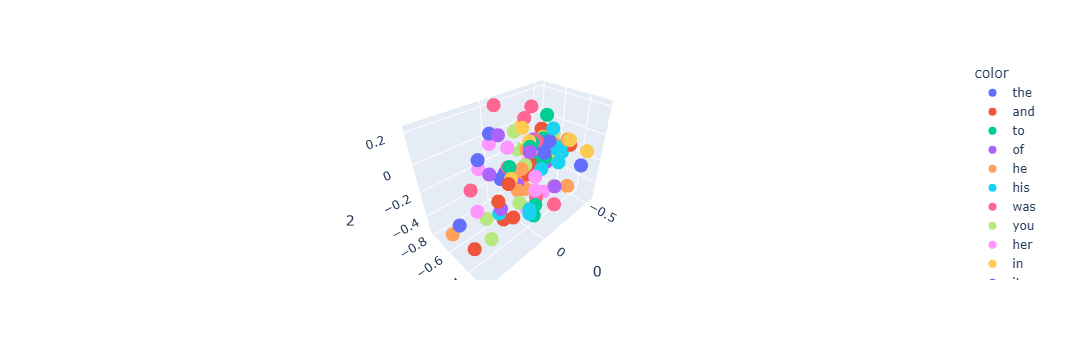

In [113]:
import plotly.express as px

fig = px.scatter_3d(
    X[:100],
    x=0,
    y=1,
    z=2,
    color=y[:100]
)

fig.show()

# Text Classification

In [114]:
import pandas as pd
import numpy as np

In [115]:
df=pd.read_csv('IMDB Dataset.csv')

In [118]:
df=df.iloc[:10000]

In [119]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
9995,"Fun, entertaining movie about WWII German spy ...",positive
9996,Give me a break. How can anyone say that this ...,negative
9997,This movie is a bad movie. But after watching ...,negative
9998,This is a movie that was probably made to ente...,negative


In [120]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [121]:
df['sentiment'].value_counts()

sentiment
positive    5028
negative    4972
Name: count, dtype: int64

In [123]:
df.duplicated().sum()

np.int64(17)

In [124]:
df.drop_duplicates(inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_21332\3006716147.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
# Basic Preprocessing
# Remove HTML Tags
# Remove Lowercase
# Remove StopWords

In [128]:
import re
def remove_html_tags(text):
    pattern=re.compile('<.*?>')
    return pattern.sub(r'',text)

In [129]:
df['review']=df['review'].apply(remove_html_tags)

C:\Users\admin\AppData\Local\Temp\ipykernel_21332\2177839855.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [130]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
9995,"Fun, entertaining movie about WWII German spy ...",positive
9996,Give me a break. How can anyone say that this ...,negative
9997,This movie is a bad movie. But after watching ...,negative
9998,This is a movie that was probably made to ente...,negative


In [131]:
df['review']=df['review'].str.lower()

C:\Users\admin\AppData\Local\Temp\ipykernel_21332\514805946.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [132]:
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive
...,...,...
9995,"fun, entertaining movie about wwii german spy ...",positive
9996,give me a break. how can anyone say that this ...,negative
9997,this movie is a bad movie. but after watching ...,negative
9998,this is a movie that was probably made to ente...,negative


In [138]:
from nltk.corpus import stopwords

In [140]:
sw_list=stopwords.words('english')

In [141]:
def remove_stopwords(text):
    new_text=[]
    for w in text.split():
        if w in stopwords.words('english'):
            new_text.append('')
        else:
            new_text.append(w)
    return " ".join(new_text)

In [142]:
df['review']=df['review'].apply(remove_stopwords)

C:\Users\admin\AppData\Local\Temp\ipykernel_21332\1478176011.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [143]:
x=df.iloc[:,0]
y=df['sentiment']

from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
y=label.fit_transform(y)


In [144]:
y

array([1, 1, 1, ..., 0, 0, 1], shape=(9983,))

In [145]:
x

0       one    reviewers  mentioned   watching  1 oz e...
1        wonderful little production.  filming techniq...
2        thought    wonderful way  spend time    hot s...
3       basically there's  family   little boy (jake) ...
4       petter mattei's "love   time  money"   visuall...
                              ...                        
9995    fun, entertaining movie  wwii german spy (juli...
9996    give   break.   anyone say     "good hockey mo...
9997     movie   bad movie.   watching  endless series...
9998       movie   probably made  entertain  middle sc...
9999    smashing film  film-making. shows  intense  st...
Name: review, Length: 9983, dtype: object

In [146]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

# Applying Bag of Words

In [147]:
from sklearn.feature_extraction.text import CountVectorizer

In [148]:
cv=CountVectorizer()

In [153]:
x_train_bow=cv.fit_transform(x_train).toarray()

In [154]:
x_train_bow

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(6988, 45469))

In [155]:
x_test_bow=cv.transform(x_test).toarray()

In [156]:
x_test_bow

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2995, 45469))

In [157]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(x_train_bow, y_train)

y_pred = gnb.predict(x_test_bow)

from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score(y_test, y_pred)

0.6260434056761269

# Applying TF-IDF

In [158]:
from sklearn.ensemble import RandomForestClassifier

In [159]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(x_train).toarray()
X_test_tfidf = tfidf.transform(x_test)

rf = RandomForestClassifier()

rf.fit(X_train_tfidf, y_train)
y_pred = rf.predict(X_test_tfidf)

accuracy_score(y_test, y_pred)

0.8484140233722871

# Applying Word2Vec

In [160]:
df

,review,sentiment
0,one reviewers mentioned watching 1 oz e...,positive
1,wonderful little production. filming techniq...,positive
2,thought wonderful way spend time hot s...,positive
3,basically there's family little boy (jake) ...,negative
4,"petter mattei's ""love time money"" visuall...",positive
...,...,...
9995,"fun, entertaining movie wwii german spy (juli...",positive
9996,"give break. anyone say ""good hockey mo...",negative
9997,movie bad movie. watching endless series...,negative
9998,movie probably made entertain middle sc...,negative


In [161]:
import gensim
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

In [163]:
story=[]
for word in df['review']:
    raw_sent=sent_tokenize(word)
    for sent in raw_sent:
        story.append(simple_preprocess(sent))

In [164]:
model = gensim.models.Word2Vec(
    window=10,
    min_count=10
)

In [165]:
model.build_vocab(story)

In [166]:
model.train(story,total_examples=model.corpus_count,epochs=model.epochs)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(5427187, 6186875)

In [169]:
len(model.wv.index_to_key)

11542

In [170]:
def document_vector(doc):
    # remove out-of-vocabulary words
    doc = [word for word in doc.split() if word in model.wv.index_to_key]
    return np.mean(model.wv[doc], axis=0)

document_vector(df['review'].values[0])

array([ 0.06967419,  0.28555366,  0.11573676, -0.0772733 , -0.03415705,
       -0.30919495,  0.20511772,  0.5755709 , -0.15919963, -0.10646586,
       -0.05375555, -0.40465286,  0.06860973,  0.1852328 ,  0.03307046,
       -0.18389663,  0.02844618, -0.43449098,  0.09123354, -0.45558444,
        0.10233707,  0.02682125,  0.08699303, -0.11231056, -0.17914596,
       -0.25424808, -0.16636077, -0.27780142, -0.2317244 ,  0.04489925,
        0.3471766 , -0.00909812,  0.02536013, -0.20435998, -0.24983932,
        0.12783596,  0.07588764, -0.36123526, -0.18724617, -0.5079372 ,
        0.11419991, -0.11904975, -0.09170976, -0.01408574,  0.32834888,
       -0.1124609 , -0.247408  , -0.07297757,  0.05872533,  0.18160376,
        0.07973965, -0.27022836, -0.23950504, -0.0873576 , -0.26212028,
        0.02192893,  0.30037954,  0.09430403, -0.21403661,  0.00284679,
        0.00195791,  0.18522301, -0.07337972,  0.01843081, -0.33226892,
        0.26207486, -0.00514516,  0.18988591, -0.47622117,  0.22

In [171]:
from tqdm import tqdm

X = []

for doc in tqdm(df['review'].values):
    X.append(document_vector(doc))

X = np.array(X)

100%|█████████████████████████████████████████████████████████████████████████████| 9983/9983 [01:33<00:00, 106.44it/s]


In [172]:
y

array([1, 1, 1, ..., 0, 0, 1], shape=(9983,))

In [173]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [174]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [175]:
rf=RandomForestClassifier()

In [176]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [177]:
y_pred=rf.predict(x_test)

In [178]:
accuracy_score(y_test,y_pred)

0.7791687531296946

# Parts of Speech Tagging

In [179]:
import spacy 

In [180]:
nlp=spacy.load('en_core_web_sm')

In [187]:
doc=nlp('I will google about facebook')

In [188]:
doc[0]

I

In [189]:
doc[1]

will

In [196]:
doc[1].pos_    # Course graint parts of sppech

'AUX'

In [197]:
doc[1].tag_    # Fine graint parts of speech

'MD'

In [191]:
doc[2].pos_

'VERB'

In [192]:
 doc[2].tag_

'VB'

In [194]:
doc[0].tag_

'PRP'

In [195]:
spacy.explain('PRP')

'pronoun, personal'

In [200]:
for word in doc:
    print(word.text, "------>", word.pos_,word.tag_,spacy.explain(word.tag_))

I ------> PRON PRP pronoun, personal
will ------> AUX MD verb, modal auxiliary
google ------> VERB VB verb, base form
about ------> ADP IN conjunction, subordinating or preposition
facebook ------> PROPN NNP noun, proper singular


In [203]:
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm")

text = "The quick brown fox jumped over the lazy dog"

doc6 = nlp(text)   # Convert string to Doc object

displacy.render(doc6, style='dep', jupyter=True)

In [204]:
options={
    'distance':80,
    'compact':True
}

In [205]:
displacy.render(doc6, style='dep', jupyter=True,options=options)